Load necessary packages

In [1]:
# only sources used were the provided course materials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

Load dataset

In [ ]:
churn_data = pd.read_csv('churn_clean.csv')

Extract the variables of interest

In [3]:
rf_data = churn_data[[
    "Churn",
    "Outage_sec_perweek",
    "Income",
    "Gender",
    "Marital",
    "State",
    "Area",
    "Techie",
    "Contract",
    "Port_modem",
    "Tablet",
    "InternetService",
    "Phone",
    "Multiple",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod",
    "Tenure",
    "MonthlyCharge",
    "Bandwidth_GB_Year"
]].copy()

Check for duplicates, and remove if necessary

In [4]:
print(rf_data.duplicated().sum())

# no duplicates were found in the dataset, so no rows will be dropped

0


Check data types, and correct if necessary

In [5]:
print(rf_data.dtypes)

# all columns are of the correct data type, so no changes will be made

Churn                  object
Outage_sec_perweek    float64
Income                float64
Gender                 object
Marital                object
State                  object
Area                   object
Techie                 object
Contract               object
Port_modem             object
Tablet                 object
InternetService        object
Phone                  object
Multiple               object
OnlineSecurity         object
OnlineBackup           object
DeviceProtection       object
TechSupport            object
StreamingTV            object
StreamingMovies        object
PaperlessBilling       object
PaymentMethod          object
Tenure                float64
MonthlyCharge         float64
Bandwidth_GB_Year     float64
dtype: object


Check for missing values, and correct if neccesary

In [6]:
print(rf_data.isna().sum())

Churn                    0
Outage_sec_perweek       0
Income                   0
Gender                   0
Marital                  0
State                    0
Area                     0
Techie                   0
Contract                 0
Port_modem               0
Tablet                   0
InternetService       2129
Phone                    0
Multiple                 0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
PaperlessBilling         0
PaymentMethod            0
Tenure                   0
MonthlyCharge            0
Bandwidth_GB_Year        0
dtype: int64


In [7]:
# missing values are present in the InternetService column, which should have been the "None" response
# the missing values will be replaced with the string "None"

# create the imputer object for categorical columns using the most frequent strategy
imputer = SimpleImputer(
    strategy='constant',
     fill_value='None')  

#impute the missing values in categorical columns using the imputer object
rf_data["InternetService"] = imputer.fit_transform(rf_data[["InternetService"]]).ravel()  

#print the missing values count after imputation
print(rf_data.isna().sum())

Churn                 0
Outage_sec_perweek    0
Income                0
Gender                0
Marital               0
State                 0
Area                  0
Techie                0
Contract              0
Port_modem            0
Tablet                0
InternetService       0
Phone                 0
Multiple              0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
PaperlessBilling      0
PaymentMethod         0
Tenure                0
MonthlyCharge         0
Bandwidth_GB_Year     0
dtype: int64


Encode categorical variables

In [8]:
# one-hot encode the nominal categorical columns
rf_data = pd.get_dummies(rf_data, columns=[
    "Gender", 
    "Marital", 
    "State", 
    "Area", 
    "PaymentMethod"
    ], 
    drop_first=False
    )

# ordinal encode the ordinal categorical columns
contract_order = {'Month-to-month': 1, 'One year': 2, 'Two Year': 3}
rf_data["Contract"] = rf_data["Contract"].map(contract_order)

# binary encode the binary yes/no categorical columns
binary_cols = [
    "Churn",
    "Techie",
    "Port_modem",
    "Tablet",
    "Phone",
    "Multiple",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]
rf_data[binary_cols] = rf_data[binary_cols].apply(
lambda col: col.map({'Yes': 1, 'No': 0})
)

#label encode the remaining categorical column
rf_data["InternetService"] = rf_data["InternetService"].map({'None': 0,'DSL': 1, 'Fiber Optic': 2})

# verify the encodings
print(rf_data.head())

   Churn  Outage_sec_perweek    Income  Techie  Contract  Port_modem  Tablet  \
0      0            7.978323  28561.99       0         2           1       1   
1      1           11.699080  21704.77       1         1           0       1   
2      0           10.752800   9609.57       1         3           1       0   
3      0           14.913540  18925.23       1         3           0       0   
4      1            8.147417  40074.19       0         1           1       0   

   InternetService  Phone  Multiple  ...  State_WI  State_WV  State_WY  \
0                2      1         0  ...     False     False     False   
1                2      1         1  ...     False     False     False   
2                1      1         1  ...     False     False     False   
3                1      1         0  ...     False     False     False   
4                2      0         0  ...     False     False     False   

   Area_Rural  Area_Suburban  Area_Urban  \
0       False          False  

Output the cleaned data to a CSV

In [9]:
rf_data.to_csv('/Users/stevenphillips/Documents/WGU/D603/d603-machine-learning/rf_data.csv', index=False)

Split the data into training and test sets

In [10]:
# separate predictors and dependent variable
X = rf_data.drop(columns=["Churn"])
y = rf_data["Churn"]

# set seed for reproducibility
SEED = 1

# split the dataset into 70% train, 15% validation, and 15% test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,
                                                    test_size=0.15,
                                                    random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                  y_train_val,
                                                  test_size=0.1765,
                                                  random_state=SEED)

# verify splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_val shape: {y_val.shape}")


X_train shape: (6999, 86)
X_test shape: (1500, 86)
X_val shape: (1501, 86)
y_train shape: (6999,)
y_test shape: (1500,)
y_val shape: (1501,)


In [11]:
# output the training, validation, and testing datasets as CSVs
train_df = X_train.copy()
train_df["Churn"] = y_train

validation_df = X_val.copy()
validation_df["Churn"] = y_val

test_df = X_test.copy()
test_df["Churn"] = y_test

train_df.to_csv("training_data.csv", index=False)
validation_df.to_csv("validation_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

Create the initial random forest and metrics

In [12]:
# instantiate rf, and fit to the training data
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
y_prob = rf.predict_proba(X_val)[:, 1]

In [13]:
# evaluate and print metrics
initial_accuracy = accuracy_score(y_val, y_pred)
initial_precision = precision_score(y_val, y_pred)
initial_recall = recall_score(y_val, y_pred)
initial_f1 = f1_score(y_val, y_pred)
initial_auc_roc = roc_auc_score(y_val, y_prob)
initial_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy:  {initial_accuracy:.4f}")
print(f"Precision: {initial_precision:.4f}")
print(f"Recall:    {initial_recall:.4f}")
print(f"F1 score:  {initial_f1:.4f}")
print(f"AUC-ROC:   {initial_auc_roc:.4f}")
print("\nConfusion matrix:")
print(initial_cm)

Accuracy:  0.8961
Precision: 0.8521
Recall:    0.7310
F1 score:  0.7869
AUC-ROC:   0.9513

Confusion matrix:
[[1057   50]
 [ 106  288]]


Perform hyperparameter tuning with k-fold cross validation

In [14]:
# set initial hyperparamters to be searched
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# run the GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# show the results for the best hyperparameters
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.8914136628203819


In [15]:
# evaluate the optimized model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_val)
y_prob = best_rf.predict_proba(X_val)[:, 1]

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_pred)
val_precision = precision_score(y_val, y_pred)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)
val_auc_roc = roc_auc_score(y_val, y_prob)
val_cm = confusion_matrix(y_val, y_pred)

# Print results
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1 Score:  {val_f1:.4f}")
print(f"Validation AUC-ROC:   {val_auc_roc:.4f}")
print("\nValidation Confusion Matrix:")
print(val_cm)

Validation Accuracy:  0.8947
Validation Precision: 0.8533
Validation Recall:    0.7234
Validation F1 Score:  0.7830
Validation AUC-ROC:   0.9486

Validation Confusion Matrix:
[[1058   49]
 [ 109  285]]


Make final predictions using the test dataset

In [16]:
y_pred_test = best_rf.predict(X_test)
y_prob_test = best_rf.predict_proba(X_test)[:, 1]

# Calculate final test metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)
test_auc_roc = roc_auc_score(y_test, y_prob_test)
test_cm = confusion_matrix(y_test, y_pred_test)

# Print final test results
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")
print(f"Test AUC-ROC:   {test_auc_roc:.4f}")
print("\nTest Confusion Matrix:")
print(test_cm)

Test Accuracy:  0.8807
Test Precision: 0.8184
Test Recall:    0.7295
Test F1 Score:  0.7714
Test AUC-ROC:   0.9362

Test Confusion Matrix:
[[1019   67]
 [ 112  302]]


Create easy comparison table of the metrics of all tests

In [17]:
metrics_table = pd.DataFrame({
    "Initial Model": [
        initial_accuracy,
        initial_precision,
        initial_recall,
        initial_f1,
        initial_auc_roc
    ],
    "Validation": [
        val_accuracy,
        val_precision,
        val_recall,
        val_f1,
        val_auc_roc
    ],
    "Final Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc_roc
    ]
},
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUC-ROC"
]).round(4)

display(metrics_table)

,Initial Model,Validation,Final Test
Accuracy,0.8961,0.8947,0.8807
Precision,0.8521,0.8533,0.8184
Recall,0.7310,0.7234,0.7295
F1 Score,0.7869,0.7830,0.7714
AUC-ROC,0.9513,0.9486,0.9362


Calculate and show feature importance

In [18]:
# calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                           Feature  Importance
16                          Tenure    0.191430
18               Bandwidth_GB_Year    0.156371
17                   MonthlyCharge    0.118558
3                         Contract    0.075474
14                 StreamingMovies    0.051226
1                           Income    0.042390
0               Outage_sec_perweek    0.039721
13                     StreamingTV    0.038528
6                  InternetService    0.017764
8                         Multiple    0.016160
2                           Techie    0.008965
4                       Port_modem    0.008728
9                   OnlineSecurity    0.008425
10                    OnlineBackup    0.008163
12                     TechSupport    0.008105
15                PaperlessBilling    0.007993
5                           Tablet    0.007659
11                DeviceProtection    0.007570
84  PaymentMethod_Electronic Check    0.007392
81                      Area_Urban    0.007312


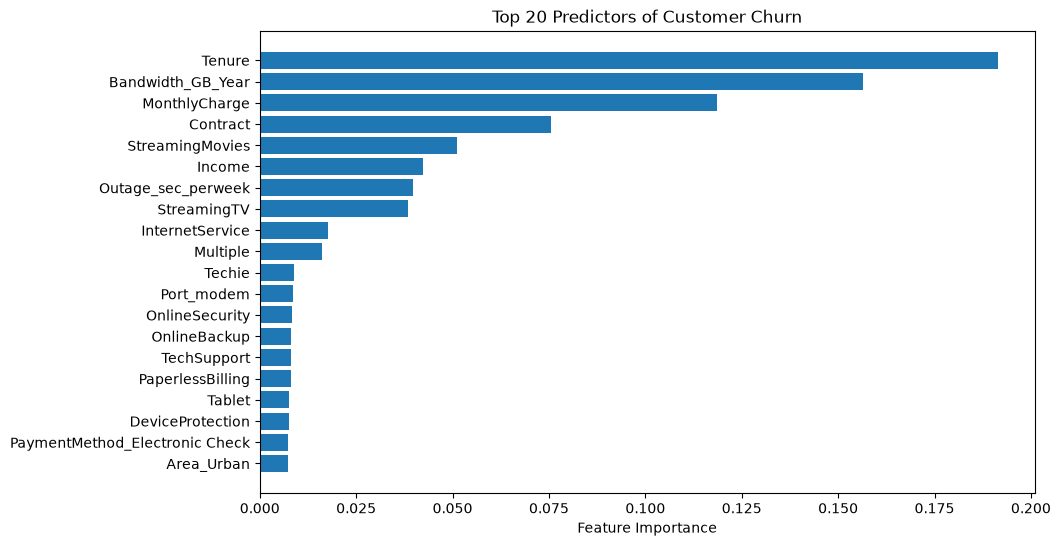

In [19]:
# plot feature importance
top = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top 20 Predictors of Customer Churn")
plt.gca().invert_yaxis()
plt.show()
